<div style="background: linear-gradient(120deg, #1ca9c9 0%, #40c4d6 60%, #7fe0e0 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Actividad 4: Procesamiento de Imagenes con Python</h1>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Laboratorio de Procesamiento de Datos</h3>
    </div>
</div>



En esta Actividad vas a construir, paso a paso, un pequeño pipeline de procesamiento de imágenes usando **una foto tomada por ti** (selfie, tu escritorio, una mascota, un objeto, etc.).

**Preparación**
* Toma una foto con tu celular y guárdala como `Data/mi_foto.jpg` (o `.png`) dentro de este repositorio.
* Ábrela con la librería que prefieras y conviértela a un arreglo de NumPy (`np.array(...)`). Verifica su `shape` y `dtype` antes de continuar.

**1.- Recorte de un elemento**
* Elige un elemento de tu foto (un ojo, un logo, un objeto pequeño) y recórtalo usando *slicing* sobre el arreglo, tal como vimos con `arr[y0:y1, x0:x1]`.

**2.-  Reescalamiento**
* Reescala el recorte para que **quepa exactamente** en la zona donde lo vas a pegar (que debe ser de otro tamaño que el recorte original).

**3.- Rotación**
* Rota el recorte reescalado un ángulo de tu elección (por ejemplo 15°, 30° o 180°) usando `ndimage.rotate` o `Image.rotate`.


**4.- Filtro gaussiano construido con NumPy**
* En lugar de usar directamente `cv2.GaussianBlur`, **construye tu propio kernel gaussiano 2D con NumPy** a partir de la fórmula:
$$ G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}} $$
usando `np.meshgrid` para generar las coordenadas $x, y$ alrededor del centro del kernel.
* Aplica ese kernel a los **bordes** del recorte (por ejemplo con `scipy.signal.convolve2d` o `ndimage.convolve`) para suavizarlos, y compara tu resultado contra `cv2.GaussianBlur` con un `sigma` equivalente.

**5.- Fusión (blending) final**
* Pega el recorte (ya reescalado y rotado) sobre otra zona de tu foto original.


Forma: (545, 719, 3) | dtype: uint8


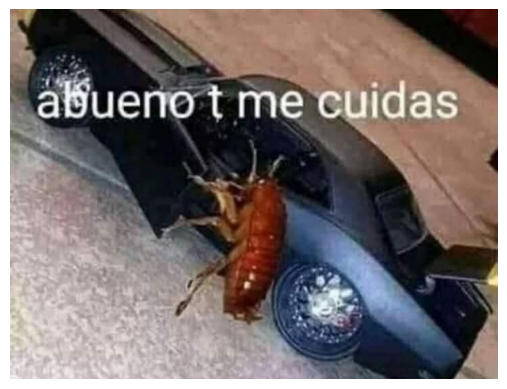

In [2]:
# 0.- cargar tu propia foto y convertirla a arreglo de NumPy
# La siguiente sección de código carga una imagen desde la carpeta Data y la convierte en un arreglo de NumPy.
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy.signal import convolve2d

mi_foto = r"C:/Users/santi/OneDrive - ITESO/ITESO/Semestre 3/Procesamiento de Datos/Laboratorio_de_Procesamiento_de_Datos_02026/Modulo I/Data/abuenotemecuidas.jpeg"  # TODO: coloca tu foto en la carpeta Data
foto = np.array(Image.open(mi_foto).convert('RGB'))
print('Forma:', foto.shape, '| dtype:', foto.dtype)
plt.imshow(foto); plt.axis('off'); plt.show()

Forma del recorte: (330, 174, 3)


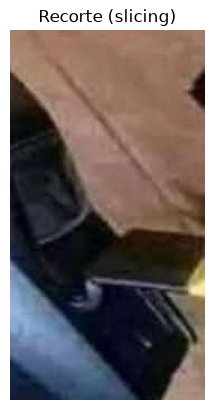

In [6]:
# Paso 1: recortar un elemento de tu foto usando slicing (elige algun elemento que te llame la atención de tu foto)

y0, y1 = 170, 500
# Invierto el orden de x0 y x1 (menor a mayor)
x0, x1 = 545, 719  

recorte = foto[y0:y1, x0:x1]

print('Forma del recorte:', recorte.shape)

plt.imshow(recorte)
plt.title('Recorte (slicing)')
plt.axis('off')
plt.show()

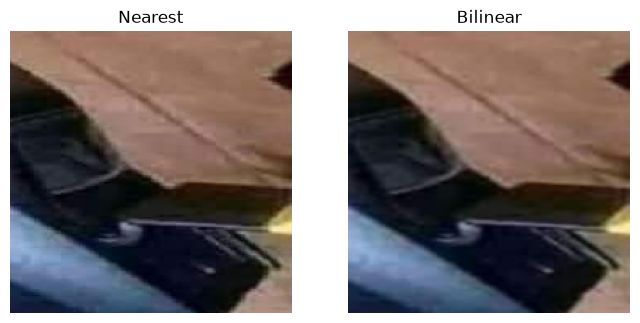

In [7]:
# Paso 2: Reescalar el recorte con dos interpolaciones distintas (usando PIL)

img_recorte_pil = Image.fromarray(recorte)
nuevo_tamano = (200, 200)

img_nearest = img_recorte_pil.resize(nuevo_tamano, resample=Image.NEAREST)
img_bilinear = img_recorte_pil.resize(nuevo_tamano, resample=Image.BILINEAR)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_nearest)
ax[0].set_title('Nearest')
ax[0].axis('off')

ax[1].imshow(img_bilinear)
ax[1].set_title('Bilinear')
ax[1].axis('off')
plt.show()

img_pequena = img_bilinear

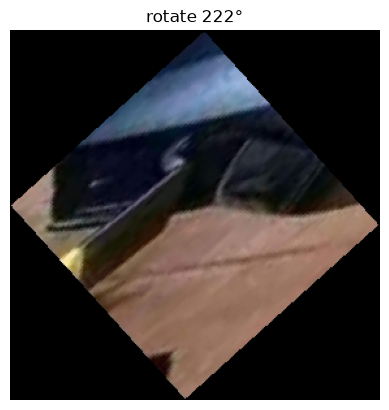

In [8]:
# Paso 3: rotar el recorte reescalado (elige tu propio ángulo de rotación)

img_rotada = img_pequena.rotate(222, expand=True)
recorte_rot = np.array(img_rotada)
plt.imshow(recorte_rot)
plt.title('rotate 222°')
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(283.5), np.float64(283.5), np.float64(-0.5))

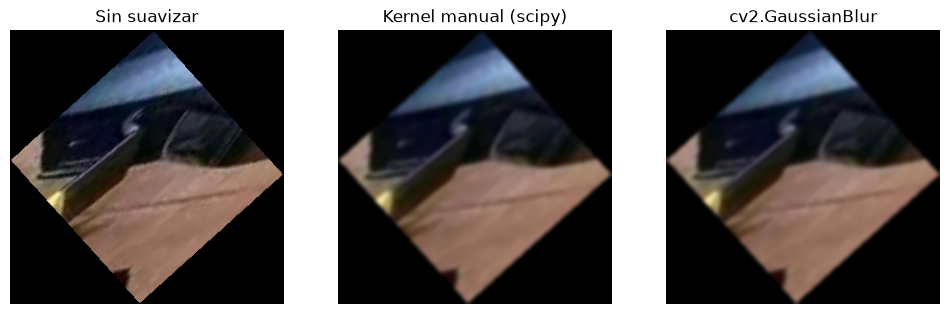

In [9]:
# Paso 4: construir un kernel gaussiano 2D con NumPy y aplicarlo
from scipy.signal import convolve2d

def kernel_gaussiano(tam=9, sigma=2):
    eje = np.arange(tam) - tam // 2
    x, y = np.meshgrid(eje, eje)  # usa np.meshgrid para generar coordenadas centradas y aplica la fórmula gaussiana
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / kernel.sum()   # normalizar para que la suma sea 1

sigma = 2
kernel = kernel_gaussiano(tam=9, sigma=sigma) #Puedes probar diferentes valores de sigma

#Aplica el kernel manual canal por canal (R, G, B), recorte_rot es tu imagen recortada del paso 2
suavizado_manual = np.stack([
    convolve2d(recorte_rot[:, :, c], kernel, mode='same', boundary='symm')
    for c in range(3)
], axis=-1).astype(np.uint8)

#Aplica el suavizado con cv2.GaussianBlur
suavizado_cv2 = cv2.GaussianBlur(recorte_rot, (9, 9), sigmaX=sigma)

#Muestra una comparación entre la imagen sin suavizar, y las imagenes suavizadas por tu kernel y por la salida del suavizado por cv2.GaussianBlur
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(recorte_rot)
ax[0].set_title('Sin suavizar')
ax[0].axis('off')

ax[1].imshow(suavizado_manual)
ax[1].set_title('Kernel manual (scipy)')
ax[1].axis('off')

ax[2].imshow(suavizado_cv2)
ax[2].set_title('cv2.GaussianBlur')
ax[2].axis('off')

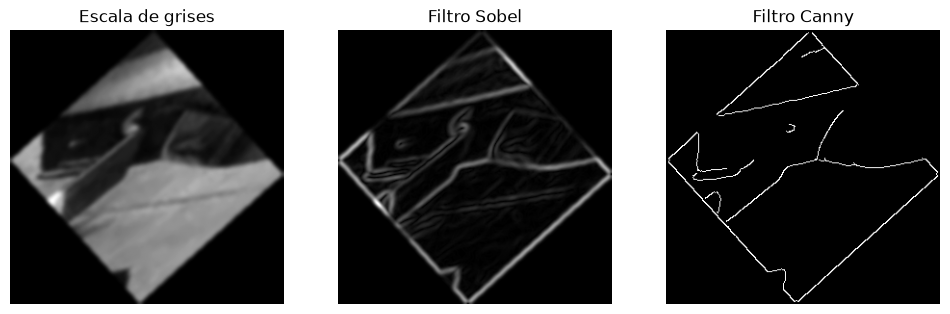

In [10]:
# Paso 5: pegar el recorte procesado sobre otra zona de la foto, fusionando bordes con la máscara gaussiana

gris = cv2.cvtColor(suavizado_cv2, cv2.COLOR_RGB2GRAY)
bordes_canny = cv2.Canny(gris, threshold1=50, threshold2=150)

sobelx = cv2.Sobel(gris, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gris, cv2.CV_64F, 0, 1, ksize=3)
bordes_sobel = cv2.magnitude(sobelx, sobely)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gris, cmap='gray')
ax[0].set_title('Escala de grises')
ax[0].axis('off')

ax[1].imshow(bordes_sobel, cmap='gray')
ax[1].set_title('Filtro Sobel')
ax[1].axis('off')

ax[2].imshow(bordes_canny, cmap='gray')
ax[2].set_title('Filtro Canny')
ax[2].axis('off')

plt.show()